You must install the tqdm library to use progress indicators with emcee


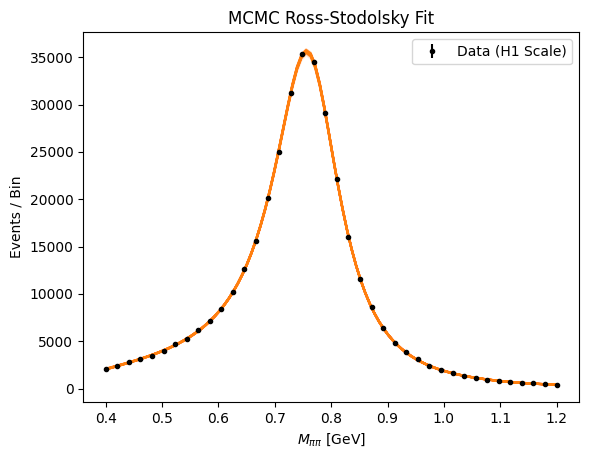

A: 4984.1966 (+21.0967, -21.4021)
M_rho: 0.7751 (+0.0003, -0.0003)
Gamma_rho: 0.1497 (+0.0008, -0.0008)
n: 3.9981 (+0.0395, -0.0385)
b0: -41.0485 (+217.1109, -247.1638)
b1: 199.9042 (+613.6718, -499.7058)
b2: -137.4982 (+282.3774, -348.7911)


In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
import scipy.optimize as op

# 1. Define the Ross-Stodolsky Model
def ross_stodolsky(M, A, M_rho, Gamma_rho, n, b0, b1, b2):
    """
    Ross-Stodolsky parameterization for rho meson mass distribution.
    Parameters:
    A: Normalization
    M_rho: Rho mass (~0.77 GeV)
    Gamma_rho: Rho width (~0.15 GeV)
    n: Skewing parameter
    b0, b1, b2: Background polynomial coefficients
    """
    # Relativistic Breit-Wigner
    q = 0.5 * np.sqrt(M**2 - 4 * 0.139**2) # Pion momentum in rho rest frame
    q0 = 0.5 * np.sqrt(M_rho**2 - 4 * 0.139**2)
    Gamma_M = Gamma_rho * (q/q0)**3 * (M_rho/M)
    
    BW = (M * M_rho * Gamma_M) / ((M**2 - M_rho**2)**2 + (M_rho * Gamma_M)**2)
    
    # Skewing term and background
    skew = (M_rho / M)**n
    background = b0 + b1*M + b2*M**2
    
    return A * BW * skew + background

# 2. Define Log-Likelihood functions for MCMC
def log_likelihood(theta, m, y, yerr):
    A, M_rho, Gamma_rho, n, b0, b1, b2 = theta
    model = ross_stodolsky(m, A, M_rho, Gamma_rho, n, b0, b1, b2)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    A, M_rho, Gamma_rho, n, b0, b1, b2 = theta
    # Broad priors based on H1 paper findings
    if 0 < A < 1e6 and 0.6 < M_rho < 0.9 and 0.05 < Gamma_rho < 0.25 and -5 < n < 5:
        return 0.0
    return -np.inf

def log_probability(theta, m, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, m, y, yerr)

# 3. Setup Synthetic Data (Replace this with the values from your table/paper)
# The paper analyzes mass ranges from ~0.4 to 1.2 GeV
m_data = np.linspace(0.4, 1.2, 40)
y_true = ross_stodolsky(m_data, 5000, 0.775, 0.150, 4.0, 10, 5, 1)
y_err = np.sqrt(y_true) # Statistical error
y_obs = y_true + np.random.normal(0, y_err)

# 4. Run MCMC
initial_guess = [4500, 0.77, 0.15, 3.5, 0, 0, 0]
n_params = len(initial_guess)
n_walkers = 32
n_steps = 2000

pos = initial_guess + 1e-4 * np.random.randn(n_walkers, n_params)

sampler = emcee.EnsembleSampler(n_walkers, n_params, log_probability, args=(m_data, y_obs, y_err))
sampler.run_mcmc(pos, n_steps, progress=True)

# 5. Results and Plotting
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
labels = ["A", "M_rho", "Gamma_rho", "n", "b0", "b1", "b2"]

# Plotting the best fit
plt.errorbar(m_data, y_obs, yerr=y_err, fmt=".k", label="Data (H1 Scale)")
m_range = np.linspace(0.4, 1.2, 100)
inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(m_range, ross_stodolsky(m_range, *sample), "C1", alpha=0.1)

plt.xlabel(r"$M_{\pi\pi}$ [GeV]")
plt.ylabel("Events / Bin")
plt.legend()
plt.title("MCMC Ross-Stodolsky Fit")
plt.show()

# Print results
for i in range(n_params):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]}: {mcmc[1]:.4f} (+{q[1]:.4f}, -{q[0]:.4f})")

You must install the tqdm library to use progress indicators with emcee


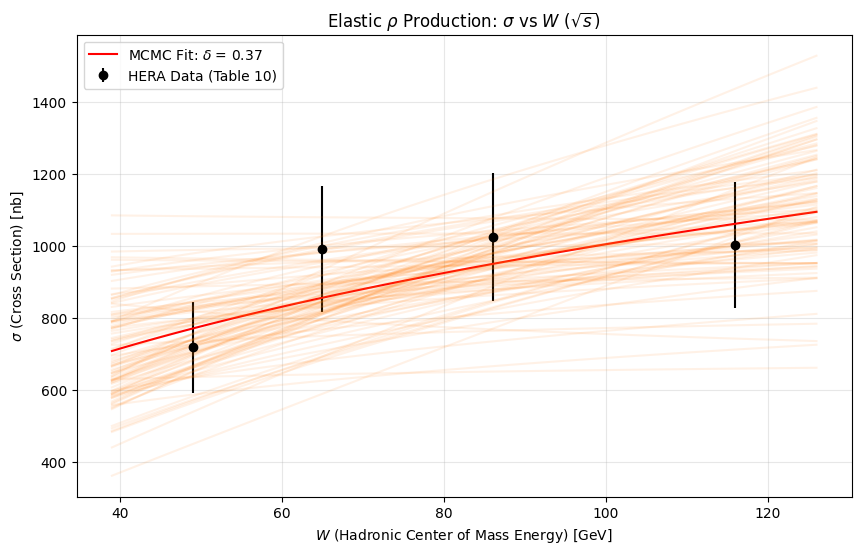

Best fit delta (Energy dependence): 0.371


In [1]:
import pandas as pd
import numpy as np
import emcee
import matplotlib.pyplot as plt
import corner

# 1. LOAD DATA FROM UPLOADED CSV (Table 10 contains Sigma vs W)
df = pd.read_csv('Table10.csv', comment='#')

# Extracting W (Energy) and Sigma (Cross Section)
# M(P=1_2) [GEV] is the energy W in these HERA tables
W = df['M(P=1_2) [GEV]'].values
sigma = df['SIG [NB]'].values
# Combining statistical and systematic errors for the MCMC weight
sigma_err = np.sqrt(df['stat +'].values**2 + df['sys +'].values**2)

# 2. DEFINE THE MODEL (Power law for Energy dependence)
# sigma(W) = A * (W/W_ref)^delta
W_ref = 75.0 # Reference energy used in HERA papers

def model(theta, W):
    A, delta = theta
    return A * (W / W_ref)**delta

# 3. MCMC FUNCTIONS
def log_likelihood(theta, W, sigma, sigma_err):
    return -0.5 * np.sum(((sigma - model(theta, W)) / sigma_err)**2)

def log_prior(theta):
    
    A, delta = theta
    if 0 < A < 5000 and -1.0 < delta < 2.0:
        return 0.0
    return -np.inf

def log_probability(theta, W, sigma, sigma_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, W, sigma, sigma_err)

# 4. RUN MCMC
ndim, nwalkers = 2, 32
initial_guess = [800.0, 0.2]
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(W, sigma, sigma_err))
sampler.run_mcmc(pos, 2000, progress=True)

# Flatten chain and get results
samples = sampler.get_chain(discard=500, thin=15, flat=True)
A_fit, delta_fit = np.median(samples, axis=0)

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))

# Plot data points
plt.errorbar(W, sigma, yerr=sigma_err, fmt='ok', label='HERA Data (Table 10)')

# Plot MCMC Fit
W_range = np.linspace(min(W)-10, max(W)+10, 100)
plt.plot(W_range, model([A_fit, delta_fit], W_range), 'r-', 
         label=f'MCMC Fit: $\delta$ = {delta_fit:.2f}')

# Plot Uncertainty (Shaded region from samples)
inds = np.random.randint(len(samples), size=100)
for ind in inds:
    sample = samples[ind]
    plt.plot(W_range, model(sample, W_range), "C1", alpha=0.1)

plt.xlabel(r'$W$ (Hadronic Center of Mass Energy) [GeV]')
plt.ylabel(r'$\sigma$ (Cross Section) [nb]')
plt.title(r'Elastic $\rho$ Production: $\sigma$ vs $W$ ($\sqrt{s}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best fit delta (Energy dependence): {delta_fit:.3f}")